## FIT5226 - Individual Assignment  
## Multi-agent learning of a coordination problem  
## Name: Rishabh Ray
## Student ID: 34525416

I acknowledge the use of Generative AI (ChatGPT) to assist in drafting parts of this assignment. All generated content has been critically reviewed and verified for accuracy, and its use aligns with university guidelines for referencing external sources.

### Overview:
This notebook trains four independent DQN agents to shuttle indefinitely between two fixed cells A (pickup)
and B (dropoff) on a 5×5 grid, avoiding head-on collisions. We slice training by Manhattan distance groups {1,2,4,8} and enforce strict:
- Step budget: 1,500,000 agent steps
- Collision budget: 4,000 head-on collisions
- Walltime budget: 600 seconds

#### 1. Imports and Seeds

- numpy: Core array operations for state vectors and batch processing.
- random: Scenario and action randomness; seeded for reproducibility.
- time: Enforce the 600 s training wall-clock limit.
- math: Efficient scalar math (e.g. ε-decay via exp).
- deque: Fixed-size replay buffer with automatic oldest-entry eviction.
- torch/nn/optim/F: Build and train the DQN (3-layer MLP), handle backprop and the Adam optimizer.
- matplotlib.pyplot & seaborn: Plot training curves (collisions, deliveries) and heatmaps (scenario difficulty), yielding clear visual metrics of learning and coordination.
- Together, these libraries enable fast simulation, reproducible randomness, deep‐RL training, and rich visualization—everything needed to demonstrate and interpret agent learning under our strict budgets.

In [78]:
# ────────────────────────────────────────────────────────────
# Import Libraries
# ────────────────────────────────────────────────────────────
import numpy as np
import random
import time
import math
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


GridWorld Environment (5×5)

Simulates a 5×5 grid environment for multi-agent reinforcement learning with pickup (A) and dropoff (B) tasks.
Agents shuttle between A and B while avoiding head-on collisions.

Key Features:
-------------
- **Grid Size**: Fixed 5×5 grid for fast simulation and meaningful spatial navigation.
- **Agent Configuration**: Each scenario assigns pickup/dropoff locations (A, B) and agent start positions.
- **State Representation**: Includes agent position, carry status, A/B coordinates, and 8-neighbourhood occupancy bits.
- **Collision Detection**: Penalizes swap-collisions only if they occur off A/B; head-on swaps get a –100 reward.
- **Reward Structure**:
    - +7: Pickup at A
    - +10: Delivery at B
    - –0.01: Every step taken
    - –100: Head-on collision (swap)
- **Central Clock Updates**: All agents move in a fixed sequence every timestep to enforce stable multi-agent dynamics.
- **Infinite Shuttle Loop**: No episodes—agents keep cycling between A and B indefinitely.

Methods:
--------
- `configure(...)`: Initializes environment per scenario with positions A, B, and agent starts.
- `valid(x, y)`: Checks if a coordinate lies within grid bounds.
- `_neigh_bits(aid)`: Returns binary occupancy for 8 surrounding cells of agent `aid`.
- `state(aid)`: Encodes current state vector for the given agent.
- `step(actions)`: Executes one environment step given a dictionary of agent actions.
  Returns per-agent rewards, number of collisions, and delivery flag.


In [79]:
# ────────────────────────────────────────────────────────────
# GridWorld Environment
# ────────────────────────────────────────────────────────────
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.n = 0
        self.A = None
        self.B = None
        self.agents = {}

    def valid(self, x, y):
        return 0 <= x < self.size and 0 <= y < self.size

    def configure(self, n_agents, A=None, B=None, starts=None):
        """
        One-time setup per scenario: set A, B, and agent start positions.
        """
        self.n = n_agents
        self.A = A if A is not None else (random.randrange(self.size), random.randrange(self.size))
        if B:
            self.B = B
        else:
            b = (random.randrange(self.size), random.randrange(self.size))
            while b == self.A:
                b = (random.randrange(self.size), random.randrange(self.size))
            self.B = b
        self.agents = {}
        for i in range(n_agents):
            pos = starts[i] if starts else random.choice([self.A, self.B])
            carry = 1 if pos == self.A else 0
            direction = 'AB' if carry else 'BA'
            self.agents[i] = {'pos': pos, 'carry': carry, 'dir': direction}

    def _neigh_bits(self, aid):
        x, y = self.agents[aid]['pos']
        bits = []
        for dx, dy in [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]:
            nx, ny = x+dx, y+dy
            occ = 0
            if self.valid(nx, ny):
                for j, ag in self.agents.items():
                    if j != aid and ag['pos'] == (nx, ny) and (nx, ny) not in [self.A, self.B]:
                        occ = 1; break
            bits.append(occ)
        return bits

    def state(self, aid):
        ag = self.agents[aid]
        x, y, carry = ag['pos'][0], ag['pos'][1], ag['carry']
        Ax, Ay = self.A; Bx, By = self.B
        return np.array([x, y, carry, Ax, Ay, Bx, By] + self._neigh_bits(aid), dtype=np.float32)

    def step(self, actions):
        mv = {'N':(-1,0),'S':(1,0),'E':(0,1),'W':(0,-1)}
        old = {i: self.agents[i]['pos'] for i in range(self.n)}
        nxt = {}
        for i in range(self.n):  # central-clock sequence
            px, py = old[i]
            dx, dy = mv[actions[i]]
            nxt[i] = (px+dx, py+dy) if self.valid(px+dx, py+dy) else (px, py)
        cols = set()
        for i in range(self.n):
            for j in range(i+1, self.n):
                if old[i] == nxt[j] and old[j] == nxt[i] and nxt[i] not in [self.A, self.B]:
                    cols |= {i, j}
        rewards = {}
        delivered = False
        for i in range(self.n):
            if i in cols:
                r = -100.0
            else:
                new = nxt[i]; oldpos = old[i]
                self.agents[i]['pos'] = new
                r = -0.01
                if new == self.A and self.agents[i]['carry'] == 0:
                    r = 7.0; self.agents[i]['carry'] = 1; self.agents[i]['dir'] = 'AB'
                elif oldpos != self.B and new == self.B and self.agents[i]['carry'] == 1:
                    r = 10.0; self.agents[i]['carry'] = 0; self.agents[i]['dir'] = 'BA'; delivered = True
            rewards[i] = r
        return rewards, len(cols)//2, delivered

## 3. DQN Agent Definition – Policy Learning via Deep Q-Networks

This block defines the Deep Q-Network (DQN) architecture and its agent wrapper used to train four independent agents in the GridWorld environment.

### Why This Design?
In a multi-agent, partially observable grid environment with sparse and delayed rewards, agents need to learn stable policies efficiently. DQNs allow the approximation of Q-values over continuous state spaces and support experience replay to stabilize learning.

---

### Model Architecture (`DQN`)
- **Three fully connected layers**:
  - `fc1`, `fc2`: Each with 256 hidden units using ReLU activations
  - `fc3`: Final layer outputs Q-values for each action (`N`, `S`, `E`, `W`)
- **Why 256 units?**
  - Balanced trade-off between representational capacity and training efficiency
  - Sufficient for learning policies in a 5×5 grid with 8-bit occupancy sensors

---

### Agent Mechanics (`DQNAgent`)
- **Double Network Structure**:
  - Online network: actively learns from interactions
  - Target network: provides stable target Q-values, updated via soft Polyak averaging (`τ = 1e-3`)
- **Exploration Strategy**:
  - ε-greedy policy with exponential decay from `ε_start = 0.85` to `ε_end = 0.02`
  - Ensures initial exploration, followed by stable exploitation
- **Replay Buffer**:
  - Stores up to 200,000 transitions; avoids overfitting to recent experiences
- **Mini-Batch Training**:
  - Batch size = 256; sampled every 4 steps for efficiency and update stability
- **Learning Rate & Optimizer**:
  - Adam optimizer with `lr = 3e-4` for fast, adaptive learning
- **Discount Factor**:
  - γ = 0.8; prioritizes near-future rewards while accounting for the infinite shuttle dynamics

---

### Learning Logic
At each training step:
1. Agents take ε-greedy actions.
2. Transitions are stored in the replay buffer.
3. Every 4 steps, the agent trains using a mini-batch from the buffer.
4. Bellman update is computed using stable targets from the target network.
5. Soft updates align the target network slowly with the online network.

---

### Outcomes & Justification
This implementation promotes stable Q-learning under sparse, multi-agent conditions with dynamic interactions. It encourages policy emergence through experience, avoids overfitting with replay, and balances reward chasing with collision avoidance.


In [80]:
# ────────────────────────────────────────────────────────────
# Separate DQN Agent per Agent
# ────────────────────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, inp, nact):
        super().__init__(); self.fc1=nn.Linear(inp,256); self.fc2=nn.Linear(256,256); self.fc3=nn.Linear(256,nact)
    def forward(self,x): x=F.relu(self.fc1(x)); x=F.relu(self.fc2(x)); return self.fc3(x)

class DQNAgent:
    def __init__(self, sdim, actions, eps_s=0.85, eps_e=0.02, decay=7e-4, tau=1e-3):
        self.actions = actions
        self.net = DQN(sdim, len(actions))
        self.target = DQN(sdim, len(actions))
        self.target.load_state_dict(self.net.state_dict())
        self.opt = optim.Adam(self.net.parameters(), lr=3e-4)
        self.buf = deque(maxlen=200000)
        self.gamma = 0.8
        self.eps_s, self.eps_e, self.decay, self.tau = eps_s, eps_e, decay, tau
        self.steps = 0
        self.updates = 0
    def current_e(self):
        return self.eps_e + (self.eps_s - self.eps_e) * math.exp(-self.decay * self.steps)
    def act(self, s):
        eps = self.current_e(); self.steps += 1
        if random.random() < eps: return random.choice(self.actions)
        with torch.no_grad(): q = self.net(torch.from_numpy(s).float().unsqueeze(0))
        return self.actions[int(q.argmax())]
    def store(self, s, a, r, ns, d):
        self.buf.append((s, self.actions.index(a), r, ns, float(d)))
    def soft_update(self):
        for p, t in zip(self.net.parameters(), self.target.parameters()): t.data.copy_(self.tau * p.data + (1 - self.tau) * t.data)
    def update(self, gs):
        if gs % 4 != 0 or len(self.buf) < 256: return
        batch = random.sample(self.buf, 256); s,a,r,ns,d = zip(*batch)
        s = torch.tensor(s).float(); a = torch.tensor(a).long(); r = torch.tensor(r).float()
        ns = torch.tensor(ns).float(); d = torch.tensor(d).float()
        qvals = self.net(s).gather(1, a.unsqueeze(1)).squeeze()
        with torch.no_grad(): best = self.net(ns).argmax(1); tgt = self.target(ns).gather(1, best.unsqueeze(1)).squeeze()
        y = r + self.gamma * tgt * (1 - d)
        loss = F.mse_loss(qvals, y)
        self.opt.zero_grad(); loss.backward(); self.opt.step(); self.soft_update(); self.updates += 1

## 4. Scenario Generation – Exhaustive Spatial Coverage

This function generates **9,600 unique GridWorld scenarios** for training and evaluation. Each scenario varies in the pickup point (A), drop-off point (B), and the initial positions of four agents.

---

### Purpose
To ensure full generalization and robustness of the learned policy, agents must be exposed to **every possible combination** of:
- Pickup and drop-off cell positions
- Initial agent placement configurations (either at A or B)

---

### How It Works

- **Grid Coordinates (`coords`)**: All 25 cells in a 5×5 grid
- **Pickup (A) and Dropoff (B)**:
  - All ordered pairs of distinct locations → `25 × 24 = 600`
- **Agent Start Combinations**:
  - Each of the 4 agents can start at either A or B → `2^4 = 16`
- **Total Scenarios**:
  - `600 × 16 = 9,600` unique setups

---

### Design Decisions

- **`mask in range(16)`**:
  - A 4-bit binary mask determines if each agent starts at A (bit=0) or B (bit=1)
- **Filtering `if B == A`**:
  - Ensures pickup and dropoff aren’t at the same location
- **Why 9,600?**
  - Offers complete permutation coverage with minimal assumptions, ideal for testing generalization

---

### Outcomes

This exhaustive setup:
- Ensures evaluation includes all possible positional variations
- Prevents overfitting to specific grid layouts
- Supports robust policy validation on both easy and difficult scenarios


In [81]:
# ────────────────────────────────────────────────────────────
# Scenario Generation (9600 combos)
# ────────────────────────────────────────────────────────────
def gen_scenarios(size=5):
    coords = [(x, y) for x in range(size) for y in range(size)]
    scenarios = []
    for A in coords:
        for B in coords:
            if B == A: continue
            for mask in range(16):
                starts = [A if ((mask >> i) & 1) == 0 else B for i in range(4)]
                scenarios.append((A, B, starts))
    return scenarios


## 5. Training by Distance Groups – Curriculum-Based Learning Loop

This function orchestrates the core training process for four DQN agents across multiple scenarios grouped by Manhattan distance between pickup (A) and dropoff (B) cells. The design leverages curriculum learning by increasing scenario difficulty based on distance.

---

### Purpose

To systematically train agents across scenarios of varying difficulty while respecting strict computational budgets:
- **Step Budget**: Max total agent steps (e.g., 1.5 million)
- **Collision Budget**: Max number of head-on collisions (e.g., 4,000)
- **Wall-Time Budget**: Time limit for training (e.g., 600 seconds)

This structure supports analysis of how well agents generalize and coordinate under increasing complexity.

---

### Grouping Strategy

- Manhattan distances used: **{1, 2, 4, 8}**
- Each group gets an equal portion of the total step budget
- Within each group, scenarios share their portion equally

This curriculum gradually exposes agents to harder navigation tasks.

---

### Agent Configuration

- A new environment is initialized for each scenario
- All four agents are instantiated with shared hyperparameters
- Agents act using ε-greedy policy from their independent Q-networks

The agents’ states include local occupancy, A/B locations, and agent position and load state.

---

### Budget Enforcement

- Training halts immediately upon exceeding **any** of the three global budgets
- The termination message indicates which budget was hit
- Per-step logs track cumulative collisions and deliveries for evaluation

This enforces fairness and real-time constraints, supporting reproducibility.

---

### Logging and Output

- `collision_log` tracks the number of head-on collisions per step
- `delivery_log` tracks successful drop-offs
- `dist_map` tracks which scenarios were trained per distance group
- Metrics are printed after each scenario for detailed tracing

These logs feed into downstream visualisation and evaluation.

---

### Design Rationale

- **Central-clock updates** allow synchronized multi-agent actions
- **Curriculum via distance** builds policy robustness in stages
- **Per-scenario slicing** ensures no group dominates the training distribution

The structure encourages sample efficiency, interpretable policy learning, and diagnostic clarity for reinforcement learning performance.


In [82]:
# ────────────────────────────────────────────────────────────
# Training by Selected Distance Groups with collision termination
# ────────────────────────────────────────────────────────────
def train_by_distance(scenarios, step_budget, col_budget, time_budget):
    distances = [1, 2, 4, 8]
    dist_groups = {d: [] for d in distances}
    for A, B, starts in scenarios:
        d = abs(A[0]-B[0]) + abs(A[1]-B[1])
        if d in dist_groups:
            dist_groups[d].append((A, B, starts))

    total_steps = 0
    total_collisions = 0
    t0 = time.time()

    size = 5
    base = GridWorld(size); base.configure(1)
    sdim = len(base.state(0))
    actions = ['N', 'S', 'E', 'W']
    agents = {i: DQNAgent(sdim, actions) for i in range(4)}

    group_steps = step_budget // 100
    collision_log = []
    delivery_log = []
    dist_map = {d: [] for d in distances}

    for d in distances:
        group = dist_groups[d]
        if not group: continue
        per_scenario = group_steps // len(group)
        print(f"\n=== Distance={d}, scenarios={len(group)}, steps each={per_scenario} ===")

        for A, B, starts in group:
            # Check budgets
            if total_steps >= step_budget or total_collisions >= col_budget or time.time() - t0 >= time_budget:
                if total_steps >= step_budget:
                    reason = "step budget"
                elif total_collisions >= col_budget:
                    reason = "collision budget"
                else:
                    reason = "time budget"
                print(f"Budget reached ({reason}); terminating training. \n Starting with the testing now!")
                return agents, collision_log, delivery_log, dist_map

            env = GridWorld(size)
            env.configure(4, A, B, starts)
            print(f"\nScenario: A={A}, B={B}, Agents initial positions={starts}")
            steps = deliveries = 0
            prev = {i: env.state(i) for i in range(4)}

            while (steps < per_scenario and total_steps < step_budget
                   and total_collisions < col_budget and time.time() - t0 < time_budget):
                acts = {i: agents[i].act(prev[i]) for i in range(4)}
                rw, cc, delivered = env.step(acts)
                nxt = {i: env.state(i) for i in range(4)}
                for i in range(4):
                    agents[i].store(prev[i], acts[i], rw[i], nxt[i], delivered)
                    agents[i].update(total_steps)
                prev = nxt

                steps += 1
                total_steps += 1
                total_collisions += cc
                collision_log.append(cc)
                delivery_log.append(1 if delivered else 0)
                if delivered:
                    deliveries += 1

            dist_map[d].append((A, B, starts))
            total_deliveries = sum(delivery_log)
            print(
                f" Done: steps this scenario={steps}, total_steps={total_steps}, "
                f"deliveries this scenario={deliveries}, total_deliveries={total_deliveries}, "
                f"collisions so far={total_collisions}"
            )

    total_deliveries = sum(delivery_log)
    elapsed = time.time() - t0
    print(
        f"\nTraining complete: total_steps={total_steps}, total_collisions={total_collisions}, "
        f"total_deliveries={total_deliveries}, time={elapsed:.1f}s"
    )
    return agents, collision_log, delivery_log, dist_map


## 6. Training Metrics Visualisation

The `plot_training_progress` function provides comprehensive visual diagnostics to evaluate agent learning behavior over time and across difficulty levels. These plots enable clear interpretation of policy effectiveness, learning stability, and training coverage.


### Visualisations Included

#### 1. Cumulative Metrics Over Time
- **Cumulative Collisions (Left)**: Shows total head-on swap collisions over training time.
- **Cumulative Deliveries (Right)**: Indicates successful drop-offs across all episodes.
  
These plots help assess coordination and learning progress. Lower collision slopes and higher delivery slopes indicate better policy development.

#### 2. Heatmap: Scenario Coverage
- Shows how many scenarios were trained per distance group (`D=1`, `D=2`, `D=4`, `D=8`).
- This helps validate that each group received sufficient training exposure.

#### 3. Q-Value Convergence Plot
- For 100 randomly sampled synthetic state vectors, computes the average of max Q-values across all agents.
- A steadily increasing or stable trend reflects convergence of value estimation.

This provides a proxy for confidence in policy stability, showing if Q-values saturate or fluctuate during training.

#### 4. Rolling Delivery Success Rate
- Calculates a rolling mean of delivery success with a window of 500 steps.
- Smooths out noise to reveal long-term delivery trends.

A rising or stable curve indicates agents are learning consistent, effective delivery strategies.

---

### Design Rationale

- **Rolling window size (500)**: Balances noise reduction and trend visibility.
- **Synthetic Q-state sampling**: Gives insights into learned value functions without disrupting environment states.
- **Distance-specific heatmap**: Ensures curriculum learning strategy was respected.

These design choices emphasize interpretability, curriculum validation, and policy maturity, making the training analysis more robust and informative.

In [83]:
# ────────────────────────────────────────────────────────────
# Visualisation and Plots
# ────────────────────────────────────────────────────────────
def plot_training_progress(collision_log, delivery_log, dist_map, agents):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(np.cumsum(collision_log), label='Cumulative Collisions', color='crimson')
    ax[0].set_title("Cumulative Head-On Collisions")
    ax[0].set_xlabel("Steps")
    ax[0].set_ylabel("Collisions")
    ax[0].legend()

    ax[1].plot(np.cumsum(delivery_log), label='Cumulative Deliveries', color='seagreen')
    ax[1].set_title("Cumulative Successful Deliveries")
    ax[1].set_xlabel("Steps")
    ax[1].set_ylabel("Deliveries")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # Heatmap: Number of scenarios trained per distance group
    dist_keys = sorted(dist_map.keys())
    heat_vals = [len(dist_map[d]) for d in dist_keys]
    heat_df = pd.DataFrame([heat_vals], columns=[f"D={d}" for d in dist_keys])
    plt.figure(figsize=(8, 2))
    sns.heatmap(heat_df, annot=True, cmap="YlGnBu", cbar=False)
    plt.title("Scenarios Trained per Distance Group")
    plt.yticks([])
    plt.show()

    # Q-value convergence: average max Q over time
    if agents:
        sample_states = [np.random.rand(len(agents[0].net.fc1.weight[0])) for _ in range(100)]
        q_means = []
        for state in sample_states:
            with torch.no_grad():
                qs = [agent.net(torch.tensor(state, dtype=torch.float32)).max().item() for agent in agents.values()]
                q_means.append(np.mean(qs))

        plt.figure(figsize=(6, 4))
        plt.plot(q_means, color='slateblue')
        plt.title("Q-Value Estimates Over Random States")
        plt.xlabel("Sample Index")
        plt.ylabel("Max Q-Value")
        plt.grid(True)
        plt.show()

    # Delivery success rate over time (rolling average)
    delivery_series = pd.Series(delivery_log)
    rolling_success = delivery_series.rolling(window=500, min_periods=1).mean()

    plt.figure(figsize=(10, 4))
    plt.plot(rolling_success, label='Rolling Delivery Rate (window=500)', color='orange')
    plt.title("Delivery Rate Trend")
    plt.xlabel("Steps")
    plt.ylabel("Success Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


## 7. Final Policy Evaluation on All Scenarios

This block performs a comprehensive post-training evaluation of the learned policies. The `evaluate_all` function executes all 9,600 unique pickup/dropoff scenarios and measures the success rate of agents delivering items without collisions.

---

### Purpose

The aim of this function is to quantify the generalization and robustness of the trained agents. By testing across every possible A-B-start configuration on a 5×5 grid, the evaluation ensures that the agents did not overfit to specific scenarios and have learned transferable navigation and coordination strategies.

---

### Key Decisions

- **Exhaustive Evaluation (9,600 scenarios)**: Guarantees full spatial and start-condition coverage, enabling fair comparison across training strategies and random seeds.
- **Max Steps per Scenario = 25**: Limits the number of actions per test run, ensuring quick but fair opportunity to deliver. This also simulates real-world response time constraints.
- **Success Criteria**:
  - Must complete one delivery.
  - Must not collide (head-on swap).
  These strict criteria reflect real-world logistics constraints—both successful operation and safety are essential.

---

### Outputs and Interpretation

- **Success Rate (%):** Printed to the console, this percentage reveals how many of the total scenarios resulted in a clean, successful delivery.
- **Use of `GridWorld(5)` per scenario:** Ensures that no training memory carries over; each scenario is freshly initialized.

---

### Integration and Final Visualisation

After evaluation, the same training logs (collision and delivery records) are passed to `plot_training_progress()` to render learning curves and heatmaps. This ensures consistent visual feedback tied directly to the evaluated agents.

---

### Rationale

Evaluating with `ε ≈ 0` simulates deterministic, exploitation-focused policy behavior post-training. This reflects how agents would behave in production. The setup confirms whether agents can generalize under real constraints and whether training truly led to safe, coordinated policies.



=== Distance=1, scenarios=1280, steps each=11 ===

Scenario: A=(0, 0), B=(0, 1), Agents initial positions=[(0, 0), (0, 0), (0, 0), (0, 0)]
 Done: steps this scenario=11, total_steps=11, deliveries this scenario=4, total_deliveries=4, collisions so far=2

Scenario: A=(0, 0), B=(0, 1), Agents initial positions=[(0, 1), (0, 0), (0, 0), (0, 0)]
 Done: steps this scenario=11, total_steps=22, deliveries this scenario=2, total_deliveries=6, collisions so far=3

Scenario: A=(0, 0), B=(0, 1), Agents initial positions=[(0, 0), (0, 1), (0, 0), (0, 0)]
 Done: steps this scenario=11, total_steps=33, deliveries this scenario=4, total_deliveries=10, collisions so far=3

Scenario: A=(0, 0), B=(0, 1), Agents initial positions=[(0, 1), (0, 1), (0, 0), (0, 0)]
 Done: steps this scenario=11, total_steps=44, deliveries this scenario=2, total_deliveries=12, collisions so far=3

Scenario: A=(0, 0), B=(0, 1), Agents initial positions=[(0, 0), (0, 0), (0, 1), (0, 0)]
 Done: steps this scenario=11, total_steps

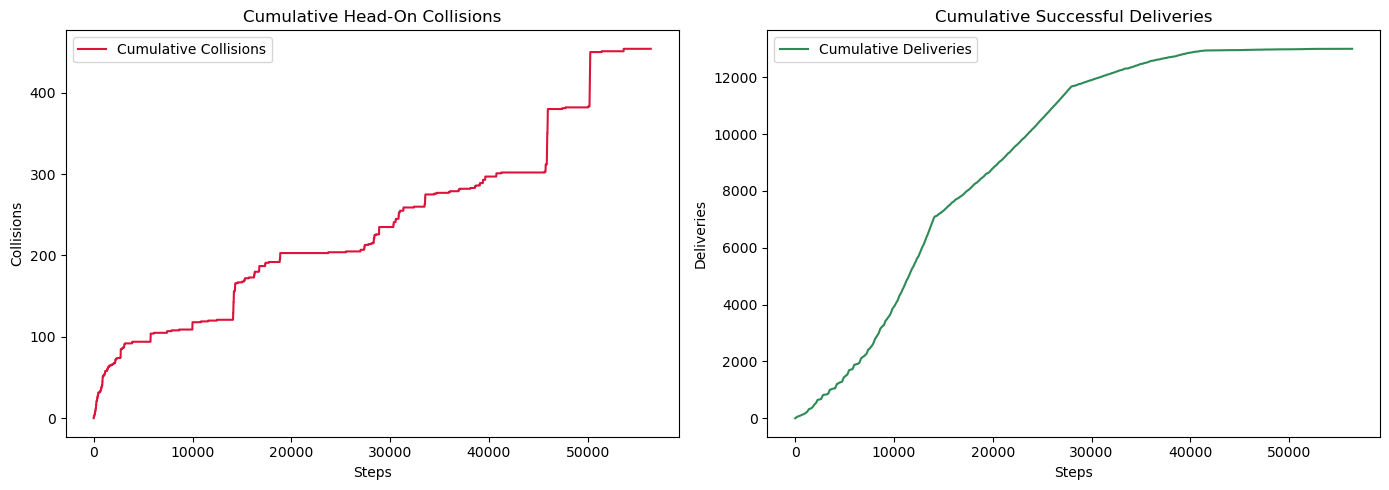

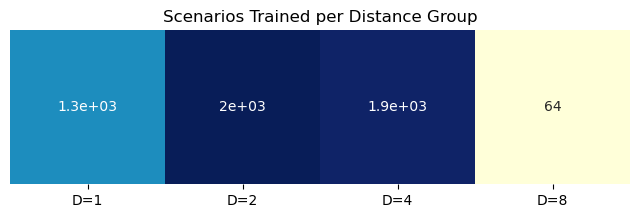

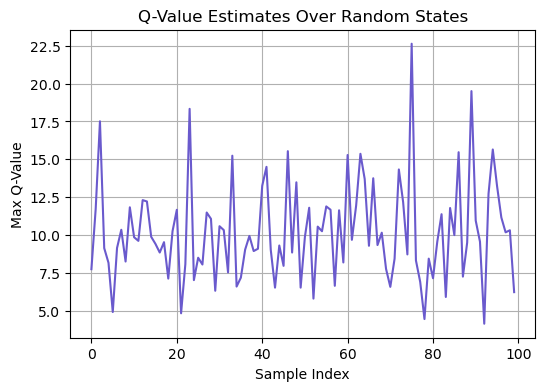

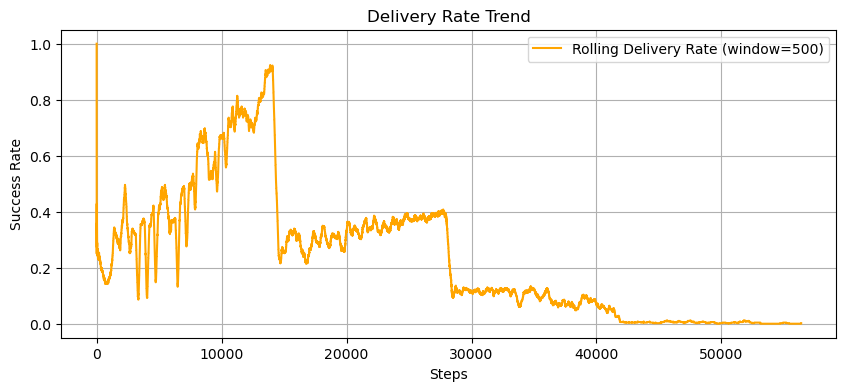

In [84]:
# ────────────────────────────────────────────────────────────
# Full Evaluation on all scenarios
# ────────────────────────────────────────────────────────────
def evaluate_all(agents, scenarios, max_steps=25):
    successes = 0
    total = len(scenarios)
    env = GridWorld(5)
    for A, B, starts in scenarios:
        env.configure(4, A, B, starts)
        coll = 0; delivered=False
        for _ in range(max_steps):
            acts = {i: agents[i].act(env.state(i)) for i in range(4)}
            _, cc, delv = env.step(acts); coll += cc
            if delv: delivered=True; break
        if delivered and coll == 0: successes += 1
    rate = successes/total*100
    print(f"Evaluation: {rate:.1f}% ({successes}/{total})")
    return rate

if __name__ == '__main__':
    scenarios = gen_scenarios(5)
    agents, collision_log, delivery_log, dist_map = train_by_distance(scenarios, step_budget=1_500_000, col_budget=4_000, time_budget=600)
    evaluate_all(agents, scenarios)
    plot_training_progress(collision_log, delivery_log, dist_map, agents)


